# Stage 2 (binary): qqbar vs rest (qg + gg)

Dedicated binary classifier to obtain a **high-purity g→qq̄ sample**.

Trained only on **matched** jets (channel2 ∈ {1,2,3}).
Target: qqbar (channel2==1) = 1 (signal), qg+gg (channel2∈{2,3}) = 0 (background).

Improvements over the 3-class model:
- `dpsi12` is **excluded from features** (it is the observable measured later — training on it would bias the measurement). It is kept only for post-hoc validation.
- log transforms on skewed variables
- engineered pairwise subjet features
- **focal loss** + balanced class weights for the ~1:7 imbalance
- monitor val PR-AUC (right metric for imbalanced signal extraction)


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TensorFlow is required for this notebook. Install it with: pip install tensorflow"
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


## 1. Paths

In [2]:
CSV_PATH = Path("merged_ML_ch2-pb80.csv")

fallback_paths = [
    Path("merged_ML_ch2-pb80.csv"),
    Path("merged_ML_ch2-pb80(1).csv"),
    Path("../csv/merged_ML_ch2-pb80.csv"),
    Path("../merged_ML_ch2-pb80.csv"),
    Path("/mnt/data/merged_ML_ch2-pb80.csv"),
]
if not CSV_PATH.exists():
    for path in fallback_paths:
        if path.exists():
            CSV_PATH = path
            break
if not CSV_PATH.exists():
    raise FileNotFoundError("Could not find merged_ML.csv. Set CSV_PATH manually.")

MODEL_DIR  = Path("models_stage2_qqbar_binary_pbpb")
OUTPUT_DIR = Path("outputs_stage2_qqbar_binary_pbpb")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Using CSV:", CSV_PATH.resolve())

Using CSV: /Users/alexmendonca/Desktop/pic2/csv/merged_ML_ch2-pb80.csv


## 2. Load + engineer features (dpsi12 KEPT as a feature)

In [3]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Stable transforms + pairwise subjet combinations.
    dpsi12 is intentionally EXCLUDED from features (it is the measured observable)."""
    df = df.copy()

    # Stabilise long-tailed positive variables
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))
    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))

    # z variables
    df["z_sum"]          = df["z1"] + df["z2"]
    df["z_absdiff"]      = np.abs(df["z1"] - df["z2"])
    df["z_min"]          = np.minimum(df["z1"], df["z2"])
    df["z_max"]          = np.maximum(df["z1"], df["z2"])
    df["z_minmax_ratio"] = df["z_min"] / (df["z_max"] + 1e-8)

    # Pairwise subjet observables (order-insensitive combinations)
    paired_bases = [
        ("N_charged3", "N_charged4", "N_charged"),
        ("N_all3",     "N_all4",     "N_all"),
        ("pt_weight3", "pt_weight4", "pt_weight"),
        ("pt_dispersion3", "pt_dispersion4", "pt_dispersion"),
    ]
    for c3, c4, name in paired_bases:
        if c3 not in df.columns or c4 not in df.columns:
            continue
        v3, v4 = df[c3], df[c4]
        vmin, vmax = np.minimum(v3, v4), np.maximum(v3, v4)
        df[f"{name}_sum"]          = v3 + v4
        df[f"{name}_absdiff"]      = np.abs(v3 - v4)
        df[f"{name}_min"]          = vmin
        df[f"{name}_max"]          = vmax
        df[f"{name}_minmax_ratio"] = vmin / (vmax + 1e-8)

    # NOTE: dpsi12 is intentionally NOT engineered into a feature.
    # It is the observable we measure later, so it must stay out of training
    # to avoid biasing the measurement (sculpting). It is dropped in the
    # feature-selection step below and used only for post-hoc validation.

    return df


df_raw = pd.read_csv(CSV_PATH)
print("Raw shape:", df_raw.shape)

df = add_engineered_features(df_raw)

ORIGINAL_TARGET = "channel2"
df = df.dropna(subset=[ORIGINAL_TARGET]).copy()
df[ORIGINAL_TARGET] = df[ORIGINAL_TARGET].astype(int)

print("Original channel2 counts:")
print(df[ORIGINAL_TARGET].value_counts().sort_index())

Raw shape: (25131, 18)
Original channel2 counts:
channel2
0    23398
1      144
2      567
3      851
4      171
Name: count, dtype: int64


## 3. Build binary target: qqbar vs rest

Keep only matched jets (channel2 ∈ {1,2,3}). Signal = qqbar (1), background = qg+gg (0).

In [4]:
KEEP = [1, 2, 3]
df = df[df[ORIGINAL_TARGET].isin(KEEP)].copy()

TARGET = "is_qqbar"
df[TARGET] = (df[ORIGINAL_TARGET] == 1).astype(np.int64)   # qqbar=1, qg+gg=0

n_sig = int((df[TARGET] == 1).sum())
n_bkg = int((df[TARGET] == 0).sum())
print(f"Signal (qqbar)      : {n_sig:,}")
print(f"Background (qg+gg)  : {n_bkg:,}")
print(f"Signal fraction     : {n_sig/(n_sig+n_bkg):.4f}")
print(f"Imbalance ratio     : 1 : {n_bkg/n_sig:.1f}")

# Columns never used as features (identifiers, raw target, and the observable).
# dpsi12 is the quantity we measure later, so it is EXCLUDED from features to
# keep the downstream <cos dpsi> measurement unbiased.
DROP_COLS = ["Event", "Jet", "Jet_pt", ORIGINAL_TARGET, TARGET, "dpsi12","tau_time"]
feature_columns = [c for c in df.columns if c not in DROP_COLS]

print(f"\nN features: {len(feature_columns)}")
print("Features:", feature_columns)

Signal (qqbar)      : 144
Background (qg+gg)  : 1,418
Signal fraction     : 0.0922
Imbalance ratio     : 1 : 9.8

N features: 37
Features: ['z1', 'z2', 'deltaR34', 'kt2', 'N_charged3', 'N_charged4', 'N_all3', 'N_all4', 'pt_weight3', 'pt_weight4', 'pt_dispersion3', 'pt_dispersion4', 'z_sum', 'z_absdiff', 'z_min', 'z_max', 'z_minmax_ratio', 'N_charged_sum', 'N_charged_absdiff', 'N_charged_min', 'N_charged_max', 'N_charged_minmax_ratio', 'N_all_sum', 'N_all_absdiff', 'N_all_min', 'N_all_max', 'N_all_minmax_ratio', 'pt_weight_sum', 'pt_weight_absdiff', 'pt_weight_min', 'pt_weight_max', 'pt_weight_minmax_ratio', 'pt_dispersion_sum', 'pt_dispersion_absdiff', 'pt_dispersion_min', 'pt_dispersion_max', 'pt_dispersion_minmax_ratio']


## 4. Event-grouped train/val/test split (no event leakage across splits)

In [5]:
X = df[feature_columns]
y = df[TARGET].to_numpy()

if "Event" in df.columns:
    groups = df["Event"].to_numpy()
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=RANDOM_STATE)
    trainval_idx, test_idx = next(gss1.split(X, y, groups=groups))

    X_trainval, X_test = X.iloc[trainval_idx], X.iloc[test_idx]
    y_trainval, y_test = y[trainval_idx], y[test_idx]
    g_trainval = groups[trainval_idx]

    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE+1)
    tr_idx, val_idx = next(gss2.split(X_trainval, y_trainval, groups=g_trainval))
    X_train, X_val = X_trainval.iloc[tr_idx], X_trainval.iloc[val_idx]
    y_train, y_val = y_trainval[tr_idx], y_trainval[val_idx]
else:
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_tmp)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"  {name} signal fraction: {yy.mean():.4f}")

Train: (524, 37)  Val: (520, 37)  Test: (518, 37)
  Train signal fraction: 0.1011
  Val signal fraction: 0.0904
  Test signal fraction: 0.0849


## 5. Impute + scale (fit on train only)

In [6]:
imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train_pp = scaler.fit_transform(imputer.fit_transform(X_train)).astype("float32")
X_val_pp   = scaler.transform(imputer.transform(X_val)).astype("float32")
X_test_pp  = scaler.transform(imputer.transform(X_test)).astype("float32")

dump({"imputer": imputer, "scaler": scaler, "features": feature_columns},
     MODEL_DIR / "qqbar_binary_preprocessor.joblib")
print("Saved preprocessor. Shapes:", X_train_pp.shape, X_val_pp.shape, X_test_pp.shape)

Saved preprocessor. Shapes: (524, 37) (520, 37) (518, 37)


## 6. Class weights

In [7]:
raw_w = compute_class_weight("balanced", classes=np.array([0,1]), y=y_train)
class_weight_map = {0: float(raw_w[0]), 1: float(raw_w[1])}
print("Balanced class weights:", class_weight_map)

Balanced class weights: {0: 0.5562632696390658, 1: 4.943396226415095}


## 7. Focal loss

Focal loss down-weights easy background and focuses learning on the rare qqbar
signal. Combined with class weights via the alpha term.

In [8]:
def binary_focal_loss(gamma=2.0, alpha=0.5):
    """Numerically stable binary focal loss."""
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        # p_t = prob of the true class
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        fl = -alpha_t * tf.pow(1.0 - p_t, gamma) * tf.math.log(p_t)
        return tf.reduce_mean(fl)
    return loss

## 8. Validation-metrics callback (PR-AUC, ROC-AUC, F1)

In [9]:
class ValMetrics(keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        p = self.model.predict(self.X_val, verbose=0).ravel()
        pred = (p >= 0.5).astype(int)
        logs["val_pr_auc"]  = average_precision_score(self.y_val, p)
        logs["val_roc_auc"] = roc_auc_score(self.y_val, p)
        logs["val_f1_sig"]  = f1_score(self.y_val, pred, pos_label=1)
        print(f"  — val_pr_auc={logs['val_pr_auc']:.4f}"
              f"  val_roc_auc={logs['val_roc_auc']:.4f}"
              f"  val_f1_sig={logs['val_f1_sig']:.4f}")

## 9. Model

In [10]:
def build_qqbar_binary_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,), name="features"),

        layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-5), name="dense_1"),
        layers.BatchNormalization(name="bn_1"),
        layers.Dropout(0.20, name="dropout_1"),

        layers.Dense(128, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-5), name="dense_2"),
        layers.BatchNormalization(name="bn_2"),
        layers.Dropout(0.20, name="dropout_2"),

        layers.Dense(64, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-5), name="dense_3"),
        layers.BatchNormalization(name="bn_3"),
        layers.Dropout(0.10, name="dropout_3"),

        layers.Dense(1, activation="sigmoid", name="qqbar_probability"),
    ], name="lund_stage2_qqbar_binary_dnn")

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=binary_focal_loss(gamma=2.0, alpha=0.5),
        metrics=[keras.metrics.AUC(name="auc_roc"),
                 keras.metrics.AUC(name="auc_pr", curve="PR")],
    )
    return model

model = build_qqbar_binary_dnn(X_train_pp.shape[1])
model.summary()

Model: "lund_stage2_qqbar_binary_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qqbar_probability (Dense)       │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,737 (206.00 KB)

 Trainable params: 51,841 (202.50 KB)

 Non-trainable params: 896 (3.50 KB)

## 10. Train

In [11]:
EPOCHS = 300
BATCH_SIZE = 1024
MONITOR = "val_pr_auc"

val_cb = ValMetrics(X_val_pp, y_val)
ckpt = keras.callbacks.ModelCheckpoint(
    str(MODEL_DIR / "qqbar_binary_dnn_best.keras"),
    monitor=MONITOR, mode="max", save_best_only=True, verbose=1)
early = keras.callbacks.EarlyStopping(
    monitor=MONITOR, mode="max", patience=15, restore_best_weights=True, verbose=1)
rlr = keras.callbacks.ReduceLROnPlateau(
    monitor=MONITOR, mode="max", factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train_pp, y_train,
    validation_data=(X_val_pp, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_map,
    callbacks=[val_cb, ckpt, early, rlr],
    verbose=1,
)
model.save(MODEL_DIR / "qqbar_binary_dnn_final.keras")
print("Best val PR-AUC:", max(history.history["val_pr_auc"]))
print("Best val ROC-AUC:", max(history.history["val_roc_auc"]))

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_pr: 0.0758 - auc_roc: 0.3480 - loss: 0.2576  — val_pr_auc=0.1227  val_roc_auc=0.5828  val_f1_sig=0.1931

Epoch 1: val_pr_auc improved from None to 0.12273, saving model to models_stage2_qqbar_binary_pbpb/qqbar_binary_dnn_best.keras

Epoch 1: finished saving model to models_stage2_qqbar_binary_pbpb/qqbar_binary_dnn_best.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - auc_pr: 0.0758 - auc_roc: 0.3480 - loss: 0.2576 - val_auc_pr: 0.1154 - val_auc_roc: 0.5836 - val_loss: 0.0933 - val_pr_auc: 0.1227 - val_roc_auc: 0.5828 - val_f1_sig: 0.1931 - learning_rate: 0.0010
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc_pr: 0.1244 - auc_roc: 0.4750 - loss: 0.2075  — val_pr_auc=0.1301  val_roc_auc=0.6112  val_f1_sig=0.1954

Epoch 2: val_pr_auc improved from 0.12273 to 0.13015, saving model to models_stage2_qqbar_binary_pbpb/qqbar_binary_dnn_best.keras

Epoch 2: finished saving model to models_stage2_qqbar_binary_pbpb/qqbar_binary_dnn_best.ker

## 11. Training curves

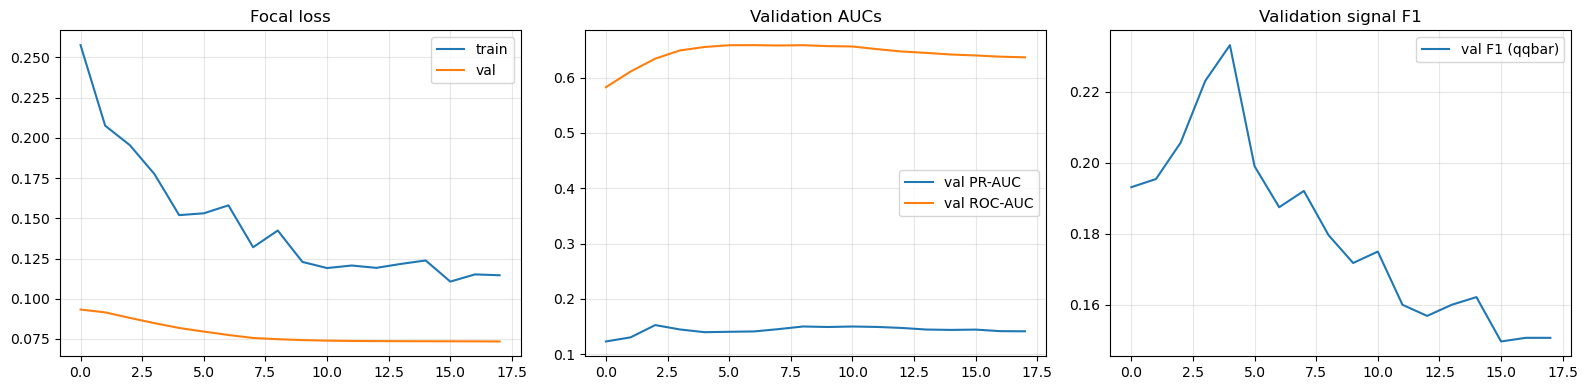

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Focal loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["val_pr_auc"],  label="val PR-AUC")
axes[1].plot(history.history["val_roc_auc"], label="val ROC-AUC")
axes[1].set_title("Validation AUCs"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history.history["val_f1_sig"], label="val F1 (qqbar)")
axes[2].set_title("Validation signal F1"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()

## 12. Test-set evaluation

Test ROC-AUC: 0.5846
Test PR-AUC : 0.1360   (baseline = signal fraction = 0.0849)

Classification report @ threshold 0.5:
              precision    recall  f1-score   support

       qg+gg       0.93      0.56      0.70       474
       qqbar       0.11      0.57      0.18        44

    accuracy                           0.56       518
   macro avg       0.52      0.56      0.44       518
weighted avg       0.86      0.56      0.66       518



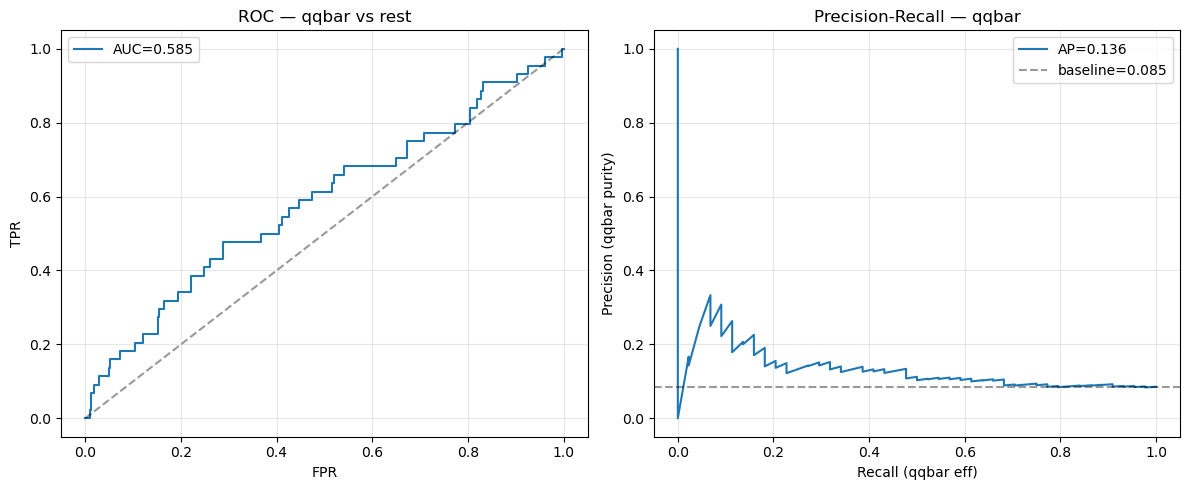

In [13]:
p_test = model.predict(X_test_pp, verbose=0).ravel()

roc = roc_auc_score(y_test, p_test)
pr  = average_precision_score(y_test, p_test)
print(f"Test ROC-AUC: {roc:.4f}")
print(f"Test PR-AUC : {pr:.4f}   (baseline = signal fraction = {y_test.mean():.4f})")
print()
print("Classification report @ threshold 0.5:")
print(classification_report(y_test, (p_test>=0.5).astype(int),
                            target_names=["qg+gg", "qqbar"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# ROC
fpr, tpr, _ = roc_curve(y_test, p_test)
axes[0].plot(fpr, tpr, label=f"AUC={roc:.3f}")
axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC — qqbar vs rest"); axes[0].legend(); axes[0].grid(alpha=0.3)
# PR
prec, rec, _ = precision_recall_curve(y_test, p_test)
axes[1].plot(rec, prec, label=f"AP={pr:.3f}")
axes[1].axhline(y_test.mean(), color="k", ls="--", alpha=0.4,
                label=f"baseline={y_test.mean():.3f}")
axes[1].set_xlabel("Recall (qqbar eff)"); axes[1].set_ylabel("Precision (qqbar purity)")
axes[1].set_title("Precision-Recall — qqbar"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_roc_pr.png", dpi=150)
plt.show()

## 13. Purity / efficiency vs threshold

This is the key table for selecting a pure qqbar sample.

 threshold  N_selected  purity  efficiency
      0.30         518  0.0849      1.0000
      0.35         517  0.0851      1.0000
      0.40         499  0.0862      0.9773
      0.45         407  0.0860      0.7955
      0.50         234  0.1068      0.5682
      0.55          75  0.1333      0.2273
      0.60          11  0.2727      0.0682
      0.65           2  0.0000      0.0000


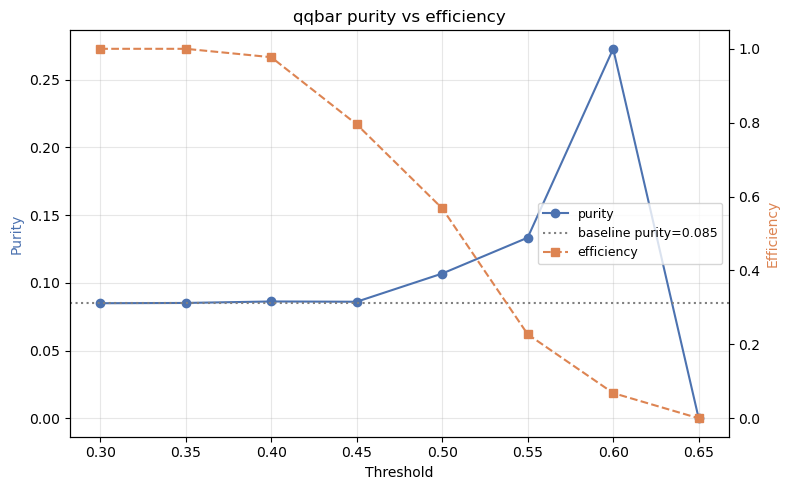

In [14]:
rows = []
for thr in np.arange(0.30, 0.96, 0.05):
    sel = p_test >= thr
    if sel.sum() == 0:
        continue
    purity = y_test[sel].mean()                      # fraction of selected that are qqbar
    eff    = (y_test[sel].sum()) / y_test.sum()       # fraction of all qqbar selected
    rows.append({"threshold": round(thr,2),
                 "N_selected": int(sel.sum()),
                 "purity": round(purity,4),
                 "efficiency": round(eff,4)})

purity_df = pd.DataFrame(rows)
print(purity_df.to_string(index=False))
purity_df.to_csv(OUTPUT_DIR / "qqbar_purity_efficiency.csv", index=False)

fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()
ax1.plot(purity_df.threshold, purity_df.purity,     "o-", color="#4c72b0", label="purity")
ax2.plot(purity_df.threshold, purity_df.efficiency, "s--", color="#dd8452", label="efficiency")
ax1.axhline(y_test.mean(), color="grey", ls=":", label=f"baseline purity={y_test.mean():.3f}")
ax1.set_xlabel("Threshold"); ax1.set_ylabel("Purity", color="#4c72b0")
ax2.set_ylabel("Efficiency", color="#dd8452")
ax1.set_title("qqbar purity vs efficiency")
l1,lb1 = ax1.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc="center right", fontsize=9)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "purity_efficiency.png", dpi=150)
plt.show()

## 14. Physics validation — cos(Δψ) of the selected qqbar sample

thr    purity   eff     N        <cos2psi>    err
0.300  0.085   1.000      518  -0.4576   0.0280
0.325  0.085   1.000      518  -0.4576   0.0280
0.350  0.085   1.000      517  -0.4573   0.0280
0.375  0.084   0.977      512  -0.4560   0.0283
0.400  0.086   0.977      499  -0.4508   0.0287
0.425  0.087   0.932      469  -0.4427   0.0300
0.450  0.086   0.795      407  -0.4163   0.0328
0.475  0.094   0.682      318  -0.3616   0.0385
0.500  0.107   0.568      234  -0.3267   0.0449
0.525  0.123   0.432      155  -0.3201   0.0546
0.550  0.133   0.227       75  -0.3274   0.0771

TRUE qqbar : <2*cos(dpsi)> = -0.5022  (N=44)
TRUE qg+gg : <2*cos(dpsi)> = -0.4535  (N=474)


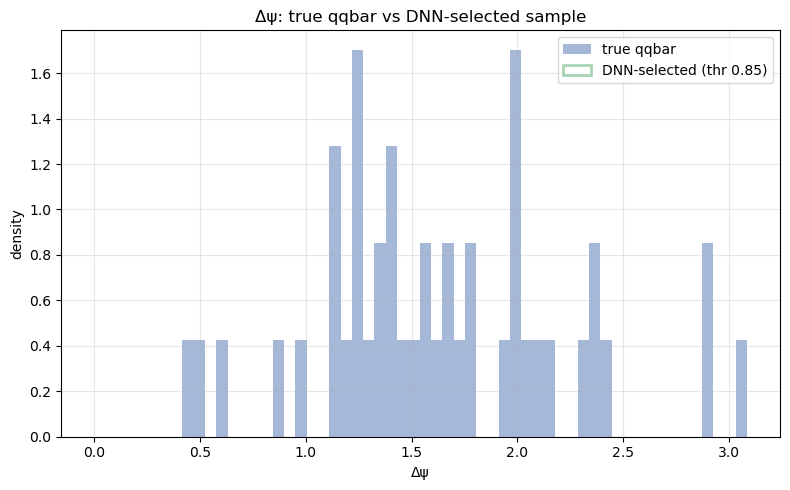

In [17]:
# g->qqbar should show <cos(dpsi)> < 0  (planes anti-correlated)
# Recover dpsi12 for the test rows
test_dpsi = df.loc[X_test.index, "dpsi12"].to_numpy()

print("thr    purity   eff     N        <cos2psi>    err")
for thr in np.arange(0.30, 0.62, 0.025):
    sel = p_test >= thr
    n = int(sel.sum())
    if n < 50:                      # skip when too few jets to be meaningful
        continue
    cosd = np.cos(2 * test_dpsi[sel])
    pur  = y_test[sel].mean()
    eff  = y_test[sel].sum() / y_test.sum()
    err  = cosd.std() / np.sqrt(n)
    print(f"{thr:.3f}  {pur:.3f}   {eff:.3f}  {n:7d}  {cosd.mean():+.4f}   {err:.4f}")

# Compare with true qqbar and true qg+gg
print()
true_qqbar = np.cos(2 * test_dpsi[y_test==1])
true_rest  = np.cos(2 * test_dpsi[y_test==0])
print(f"TRUE qqbar : <2*cos(dpsi)> = {true_qqbar.mean():+.4f}  (N={(y_test==1).sum():,})")
print(f"TRUE qg+gg : <2*cos(dpsi)> = {true_rest.mean():+.4f}  (N={(y_test==0).sum():,})")

# Plot dpsi distribution for selected vs rest
fig, ax = plt.subplots(figsize=(8,5))
sel85 = p_test >= 0.85
ax.hist(test_dpsi[y_test==1], bins=50, density=True, alpha=0.5,
        label="true qqbar", color="#4c72b0")
ax.hist(test_dpsi[sel85], bins=50, density=True, alpha=0.5,
        label="DNN-selected (thr 0.85)", color="#55a868", histtype="step", lw=2)
ax.set_xlabel("Δψ"); ax.set_ylabel("density")
ax.set_title("Δψ: true qqbar vs DNN-selected sample")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dpsi_validation.png", dpi=150)
plt.show()